# Testanto modelo NGBoost para predição de Resistência à compressão do concreto

In [5]:
%%capture
!pip install ngboost

In [6]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import GroupKFold, cross_val_score
from ngboost.distns import Normal
from ngboost import NGBRegressor
from ngboost.scores import MLE
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm.notebook import tqdm
from scipy import stats
from scipy.stats import spearmanr
import os, math
import seaborn as sns
import pandas as pd
import numpy as np

In [4]:
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'
filename = 'df_resistencia_sem_feature_engineering.pkl'
file_path = os.path.join(dirpath, filename)
os.listdir(dirpath)
df = pd.read_pickle(file_path)
df['target'] = df['Resistencia_Compressao_MPa'].copy()
df.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 551 entries, 15 to 598
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Autores/ano                  551 non-null    object 
 1   Massa_Esp_Cimento_g_cm3      551 non-null    float64
 2   Finura_Cimento_Blaine_m2_kg  551 non-null    float64
 3   Massa_Esp_Filer_g_cm3        551 non-null    float64
 4   Massa_Esp_Areia_g_cm3        551 non-null    float64
 5   Massa_Esp_Brita_g_cm3        551 non-null    float64
 6   Cimento_kg_m3                551 non-null    float64
 7   Filer_Calcario_kg_m3         551 non-null    float64
 8   Agua_kg_m3                   551 non-null    float64
 9   Agregado_Miudo_Total_kg_m3   551 non-null    float64
 10  Agregado_Graudo_Total_kg_m3  551 non-null    float64
 11  Superplastificante_kg_m3     551 non-null    float64
 12  Relacao_Agua_Cimento         551 non-null    float64
 13  idade                   

In [8]:
n_groups = df['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 17


In [9]:
hyper_params = {
    "Dist": Normal,
    "natural_gradient": True,
    "learning_rate": 0.01,
    "n_estimators": 200,
    "col_sample": 0.2,
    "minibatch_frac": 0.5,
    "verbose": False,
}

In [10]:
%%time
X = df.drop(columns=['target', 'Autores/ano'])
y = df['target']
groups = df['Autores/ano']

all_preds = []
all_true = []
all_groups = []
results = []
importancias_xgb = []
all_mu = []
all_sigma = []

for fold, (train_idx, val_idx) in tqdm(enumerate(gkf.split(X, y, groups)), total=n_groups, desc="Folds", unit="fold"):

    model = NGBRegressor(**hyper_params)

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    model.fit(X_train, y_train)

    pred_dist = model.pred_dist(X_val)

    mu = pred_dist.loc
    sigma = pred_dist.scale

    all_mu.extend(mu)
    all_sigma.extend(sigma)

    all_preds.extend(mu)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])
    importancias_xgb.append(model.feature_importances_)

Folds:   0%|          | 0/17 [00:00<?, ?fold/s]

CPU times: user 22.4 s, sys: 16.9 ms, total: 22.4 s
Wall time: 22.8 s


In [11]:
cv_results = pd.DataFrame({
    "y_true": all_true,
    "mu": all_mu,
    "sigma": all_sigma,
    "group": all_groups
})

cv_results["residual"] = (
    cv_results["y_true"] -
    cv_results["mu"]
)

cv_results["z"] = (
    cv_results["y_true"] -
    cv_results["mu"]
) / cv_results["sigma"]

cv_results["abs_error"] = (
    cv_results["y_true"] -
    cv_results["mu"]
).abs()

cv_results["ape"] = (
    cv_results["y_true"] -
    cv_results["mu"]).abs() / cv_results["y_true"].abs()

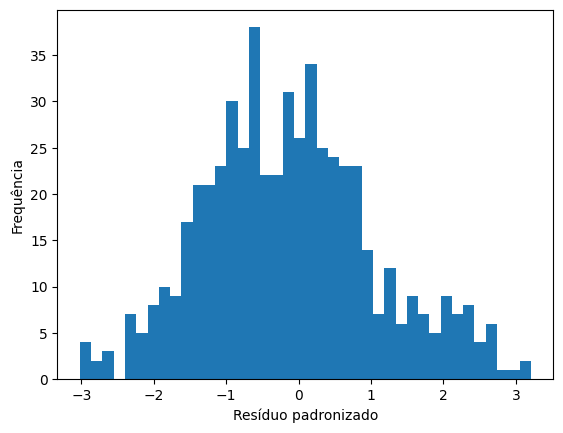

In [12]:
plt.hist(cv_results["z"], bins=40)
plt.xlabel("Resíduo padronizado")
plt.ylabel("Frequência")
plt.show()

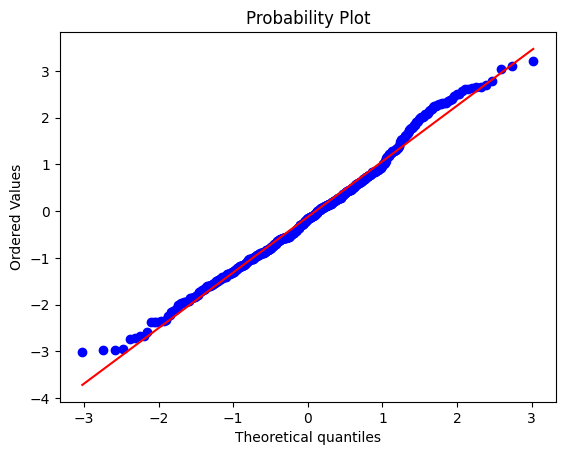

In [13]:
stats.probplot(
    cv_results["z"],
    dist="norm",
    plot=plt
)

plt.show()

In [14]:
lower = cv_results["mu"] - 1.96 * cv_results["sigma"]
upper = cv_results["mu"] + 1.96 * cv_results["sigma"]

coverage = (
    (cv_results["y_true"] >= lower) &
    (cv_results["y_true"] <= upper)
).mean()

print(coverage)

0.8838475499092558


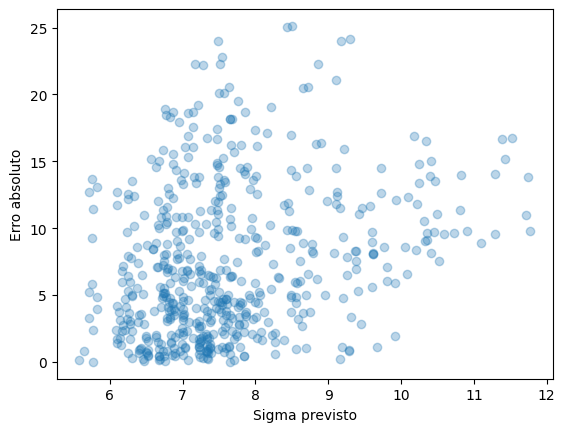

In [15]:
plt.scatter(
    cv_results["sigma"],
    cv_results["abs_error"],
    alpha=0.3
)

plt.xlabel("Sigma previsto")
plt.ylabel("Erro absoluto")
plt.show()

In [16]:
cv_results[["sigma", "abs_error"]].corr()

,sigma,abs_error
sigma,1.00000,0.27575
abs_error,0.27575,1.00000


In [17]:
spearmanr(
    cv_results["sigma"],
    cv_results["abs_error"]
)

SignificanceResult(statistic=np.float64(0.2698571488439714), pvalue=np.float64(1.1952821661486308e-10))

In [18]:
rmse = np.sqrt(np.mean((cv_results["y_true"] - cv_results["mu"])**2))
sigma_mean = np.mean(cv_results["sigma"])

print(rmse, sigma_mean)

9.232236577842514 7.636095123185646


In [19]:
z = (cv_results["y_true"] - cv_results["mu"]) / cv_results["sigma"]

print(z.mean())
print(z.std())

-0.12346545390472655
1.1916265422976613


In [20]:
cv_results["sigma"].describe()

,sigma
count,551.000000
mean,7.636095
std,1.189737
min,5.582159
25%,6.823688
50%,7.376353
75%,8.067902
max,11.775212


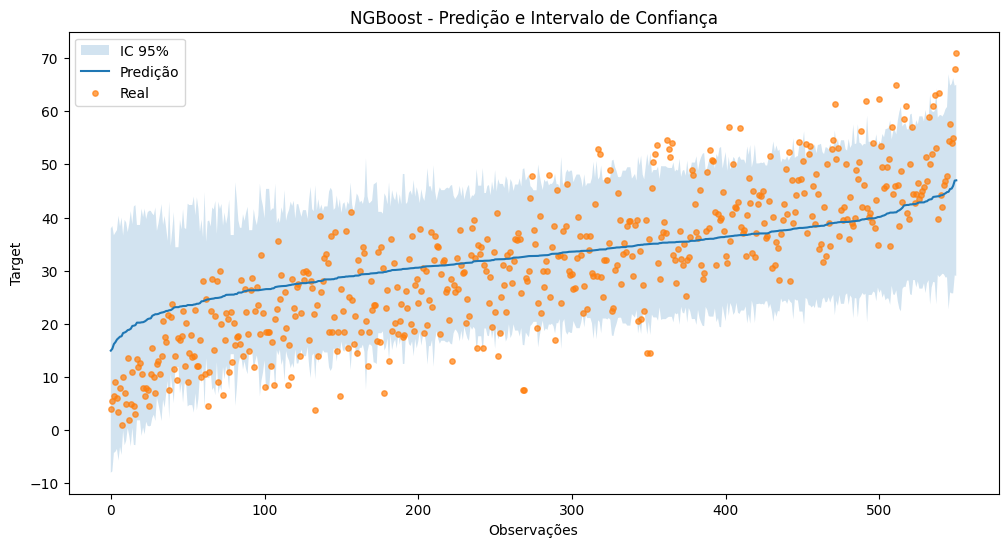

In [21]:
plot_df = cv_results.copy()

plot_df["lower"] = (
    plot_df["mu"] - 1.96 * plot_df["sigma"]
)

plot_df["upper"] = (
    plot_df["mu"] + 1.96 * plot_df["sigma"]
)

plot_df = plot_df.sort_values("mu")

x = np.arange(len(plot_df))

plt.figure(figsize=(12,6))

plt.fill_between(
    x,
    plot_df["lower"],
    plot_df["upper"],
    alpha=0.2,
    label="IC 95%"
)

plt.plot(
    x,
    plot_df["mu"],
    label="Predição"
)

plt.scatter(
    x,
    plot_df["y_true"],
    s=15,
    alpha=0.7,
    label="Real"
)

plt.legend()
plt.xlabel("Observações")
plt.ylabel("Target")
plt.title("NGBoost - Predição e Intervalo de Confiança")
plt.show()

## Gráfico menos poluido

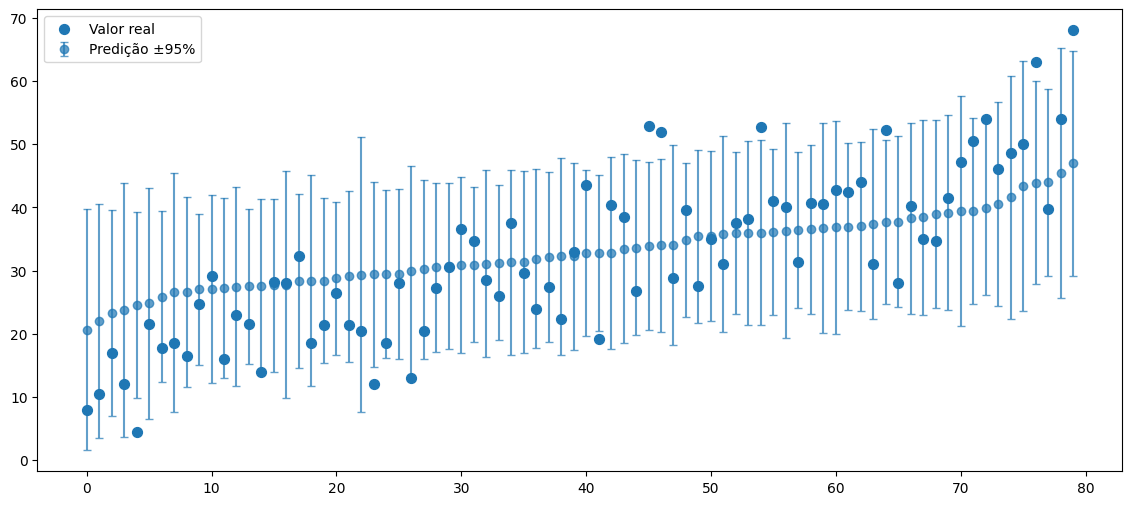

In [22]:
sample = cv_results.sample(
    80,
    random_state=42
).sort_values("mu")

x = np.arange(len(sample))

plt.figure(figsize=(14,6))

plt.errorbar(
    x,
    sample["mu"],
    yerr=1.96 * sample["sigma"],
    fmt="o",
    alpha=0.7,
    capsize=3,
    label="Predição ±95%"
)

plt.scatter(
    x,
    sample["y_true"],
    s=50,
    label="Valor real"
)

plt.legend()
plt.show()

## Observado vs Previsto

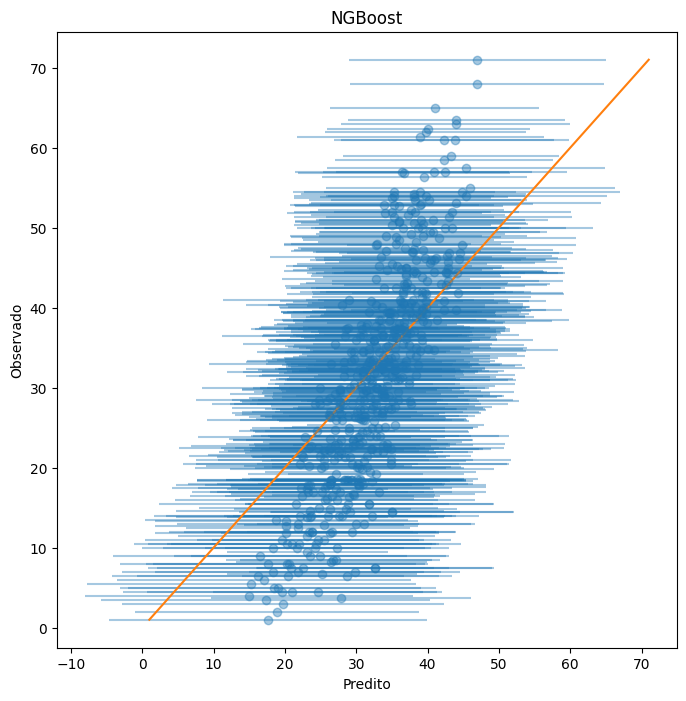

In [23]:
plt.figure(figsize=(8,8))

plt.errorbar(
    cv_results["mu"],
    cv_results["y_true"],
    xerr=1.96 * cv_results["sigma"],
    fmt="o",
    alpha=0.4
)

lims = [
    min(cv_results["y_true"].min(),
        cv_results["mu"].min()),
    max(cv_results["y_true"].max(),
        cv_results["mu"].max())
]

plt.plot(lims, lims)

plt.xlabel("Predito")
plt.ylabel("Observado")
plt.title("NGBoost")
plt.show()

## Observações fora de faixa

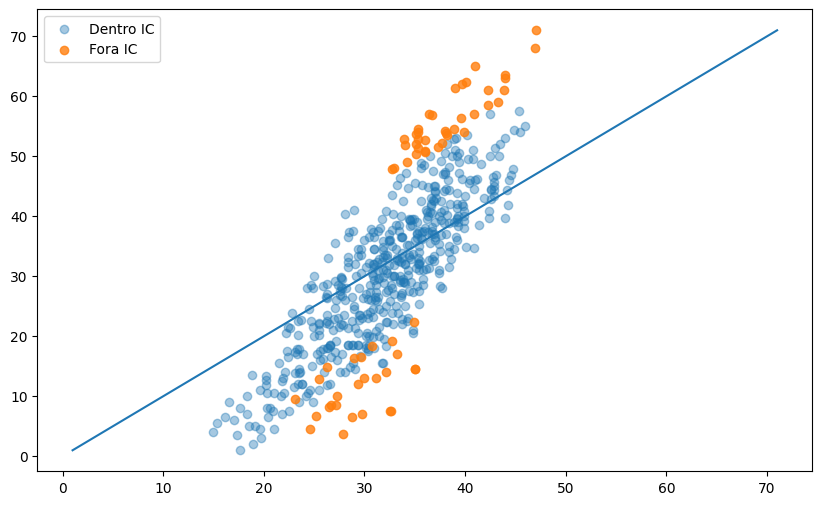

In [24]:
cv_results["lower"] = (
    cv_results["mu"] -
    1.96 * cv_results["sigma"]
)

cv_results["upper"] = (
    cv_results["mu"] +
    1.96 * cv_results["sigma"]
)

cv_results["inside"] = (
    (cv_results["y_true"] >= cv_results["lower"])
    &
    (cv_results["y_true"] <= cv_results["upper"])
)

plt.figure(figsize=(10,6))

plt.scatter(
    cv_results.loc[cv_results.inside, "mu"],
    cv_results.loc[cv_results.inside, "y_true"],
    alpha=0.4,
    label="Dentro IC"
)

plt.scatter(
    cv_results.loc[~cv_results.inside, "mu"],
    cv_results.loc[~cv_results.inside, "y_true"],
    alpha=0.8,
    label="Fora IC"
)

lims = [
    min(cv_results["mu"].min(),
        cv_results["y_true"].min()),
    max(cv_results["mu"].max(),
        cv_results["y_true"].max())
]

plt.plot(lims, lims)

plt.legend()
plt.show()

In [25]:
print("R²:", r2_score(cv_results["y_true"], cv_results["mu"]) * 100)
print("RMSE:", root_mean_squared_error(cv_results["y_true"], cv_results["mu"]))
print("MAE:", mean_absolute_error(cv_results["y_true"], cv_results["mu"]))
print("MAPE:", mean_absolute_percentage_error(cv_results["y_true"], cv_results["mu"]))

R²: 54.327754526166075
RMSE: 9.232236577842514
MAE: 7.357647755049479
MAPE: 0.44644450562044236
